## The initial idea
1. Divide the image and text into meaningful segment or patches
2. Apply DWT-CNN to the image patches=img_forged_ftrs.
(remove the classifiaction and FCN layer because we only want the forged features)
3. Apply Last 4 BERT Layers + Linear layer as context aggregator to the text segments=txt_forges_ftrs
4. Generate image and text embeddings
5. image_ftrs=img_emb+img_forged_ftrs, txt_ftrs=text_emb+txt_forged_ftrs
6. Graph construction
7. Run GAT separately on Image-Image and Text-Text graphs
8. H_{text} and H_{image} through a linear layer into a shared dimension d
9. Contrastive learning: It works on pairs. It forces the embedding of a specific image patch to be very close to its corresponding text segment. 
10. CS Divergence alignment: Minimize the CS Divergence between the distribution of text and image representations. This forces the model to find a space where "Real Text" and "Real Image" look similar, making "Fake Mismatches" stand out as outliers. with kernel density estimations??
11. adaptive Cross modal  attention fusion(applying cross attention network) and adaptive modality gating


## cleaning the data

In [44]:
## importing libraries
import pandas as pd
from tqdm.auto import tqdm
import numpy as np 
import re
import matplotlib.pyplot as plt

from transformers import BertModel, BertTokenizer
from torch.utils.data import Dataset
import torch
import torch.nn.functional as F
from torch import nn

In [45]:
df_1= pd.read_csv("twitter_data/tweets_devset.txt", sep='\t') 
df_2= pd.read_csv("twitter_data/tweets_testset.txt", sep='\t')

# Write the DataFrame to a CSV file
df_1.to_csv('twitter_data/tweets_devset.csv', index=False)
df_2.to_csv('twitter_data/tweets_testset.csv', index=False)

In [46]:
df_1=pd.read_csv("twitter_data/tweets_devset.csv")
df_2=pd.read_csv("twitter_data/tweets_testset.csv")

In [47]:
df_1.shape,df_2.shape
df_1.head(5)

,tweetId,tweetText,userId,imageId(s),username,timestamp,label
0,263046056240115712,¿Se acuerdan de la película: “El día después d...,21226711,sandyA_fake_46,iAnnieM,Mon Oct 29 22:34:01 +0000 2012,fake
1,262995061304852481,@milenagimon: Miren a Sandy en NY! Tremenda i...,192378571,sandyA_fake_09,CarlosVerareal,Mon Oct 29 19:11:23 +0000 2012,fake
2,262979898002534400,"Buena la foto del Huracán Sandy, me recuerda a...",132303095,sandyA_fake_09,LucasPalape,Mon Oct 29 18:11:08 +0000 2012,fake
3,262996108400271360,Scary shit #hurricane #NY http://t.co/e4JLBUfH,241995902,sandyA_fake_29,Haaaaarryyy,Mon Oct 29 19:15:33 +0000 2012,fake
4,263018881839411200,My fave place in the world #nyc #hurricane #sa...,250315890,sandyA_fake_15,princess__natt,Mon Oct 29 20:46:02 +0000 2012,fake


In [48]:
import os
def build_image_map(image_root):

    image_map = {}

    for root, dirs, files in os.walk(image_root):
        for file in files:
            if file.endswith(".jpg") or file.endswith(".png"):
                image_id = file.split(".")[0]
                image_map[image_id] = os.path.join(root, file)

    return image_map

In [49]:
image_root = "twitter_data\MediaEval2015_DevSet_Images\Medieval2015_DevSet_Images"

image_map = build_image_map(image_root)

print(len(image_map))

358


<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Anirban Banerjee\AppData\Local\Temp\ipykernel_31376\1067555466.py:1: SyntaxWarning: invalid escape sequence '\M'
  image_root = "twitter_data\MediaEval2015_DevSet_Images\Medieval2015_DevSet_Images"


In [50]:
print(len(image_map))

358


In [51]:
df_1 = df_1[df_1["imageId(s)"].isin(image_map.keys())].reset_index(drop=True)

In [52]:
df_1.shape

(14092, 7)

## Image Embedding generation block

In [53]:
import os
import shutil
import torch
import torchvision
import numpy as np
import cv2
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

In [54]:
import transformers
print(transformers.__version__)

4.49.0


In [55]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import torch
import cv2
import numpy as np
import os
from PIL import Image
from transformers import AutoProcessor, AutoModel

from transformers import AutoModelForCausalLM, AutoProcessor

model_id = "microsoft/Florence-2-base"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    trust_remote_code=True
).to(device).eval()

processor = AutoProcessor.from_pretrained(
    model_id,
    trust_remote_code=True
)

In [ ]:

MIN_OBJ_SIZE = 128 

def get_florence_boxes(image, task_prompt="<REGION_PROPOSAL>"):
    """
    Runs Florence-2 to get bounding boxes.
    """
    inputs = processor(text=task_prompt, images=image, return_tensors="pt").to(device)
    
    generated_ids = model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        max_new_tokens=1024,
        do_sample=False,
        num_beams=3
    )
    
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    parsed_answer = processor.post_process_generation(
        generated_text, 
        task=task_prompt, 
        image_size=(image.width, image.height)
    )
    
    # Extract boxes from the dictionary
    # Region proposal returns boxes in [x1, y1, x2, y2] format
    res = parsed_answer[task_prompt]
    return np.array(res['bboxes'])

# ---------------------------
# 2. Refined Processing Logic
# ---------------------------
def grid_segments(image_np, occupied_mask, patch_size=224, force_all=False):
    h, w = image_np.shape[:2]
    patches = []
    for y in range(0, h - patch_size + 1, patch_size):
        for x in range(0, w - patch_size + 1, patch_size):
            if not force_all:
                region = occupied_mask[y:y+patch_size, x:x+patch_size]
                if np.mean(region) > 0.3: # If 30% is covered by an object, skip
                    continue
            patch = image_np[y:y+patch_size, x:x+patch_size]
            patches.append((patch, x, y))
    return patches

def process_image(image_path, save_dir, patch_size=224):
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)
    h, w = image_np.shape[:2]
    os.makedirs(save_dir, exist_ok=True)

    # Save Global Context
    cv2.imwrite(os.path.join(save_dir, "global_context.jpg"), 
                cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR))

    # Get Bounding Boxes using Florence-2
    # No scores/thresholds needed as Florence-2 proposes meaningful regions directly
    boxes = get_florence_boxes(image) 

    occupied_mask = np.zeros((h, w), dtype=np.uint8)
    meaningful_found = False
    patch_id = 0

    # Process Boxes
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        bw, bh = x2 - x1, y2 - y1
        
        # Apply Size Filter
        if bw >= MIN_OBJ_SIZE and bh >= MIN_OBJ_SIZE:
            meaningful_found = True
            cropped = image_np[y1:y2, x1:x2]
            
            filename = f"obj_{patch_id}_x{x1}_y{y1}.jpg"
            cv2.imwrite(os.path.join(save_dir, filename),
                        cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR))
            
            occupied_mask[y1:y2, x1:x2] = 1
            patch_id += 1

    # Grid logic
    if meaningful_found:
        # Fill in the holes around the objects
        grid_patches = grid_segments(image_np, occupied_mask, patch_size, force_all=False)
    else:
        # No meaningful objects? Grid the whole thing
        grid_patches = grid_segments(image_np, occupied_mask, patch_size, force_all=True)

    for patch, x, y in grid_patches:
        filename = f"grid_{patch_id}_x{x}_y{y}.jpg"
        cv2.imwrite(os.path.join(save_dir, filename),
                    cv2.cvtColor(patch, cv2.COLOR_RGB2BGR))
        patch_id += 1

    return patch_id


In [ ]:
## this is the improved version of the code, we wil apply this to increase performance with some improvements

# MIN_OBJ_RATIO = 0.1   # instead of fixed 128
# FLORENCE_INPUT_SIZE = 768  # standardize input size

# # ---------------------------
# # 1. Florence Box Extraction (with resizing + rescaling)
# # ---------------------------
# def get_florence_boxes(image, task_prompt="<REGION_PROPOSAL>"):
#     """
#     Runs Florence-2 to get bounding boxes (with resizing + rescaling).
#     """
#     orig_w, orig_h = image.size

#     # Resize image for stable Florence behavior
#     image_resized = image.resize((FLORENCE_INPUT_SIZE, FLORENCE_INPUT_SIZE))

#     inputs = processor(
#         text=task_prompt,
#         images=image_resized,
#         return_tensors="pt"
#     ).to(device)

#     generated_ids = model.generate(
#         input_ids=inputs["input_ids"],
#         pixel_values=inputs["pixel_values"],
#         max_new_tokens=1024,
#         do_sample=False,
#         num_beams=3
#     )

#     generated_text = processor.batch_decode(
#         generated_ids,
#         skip_special_tokens=False
#     )[0]

#     parsed_answer = processor.post_process_generation(
#         generated_text,
#         task=task_prompt,
#         image_size=(FLORENCE_INPUT_SIZE, FLORENCE_INPUT_SIZE)
#     )

#     res = parsed_answer[task_prompt]
#     boxes = np.array(res['bboxes'])

#     # 🔥 Rescale boxes back to original image size
#     scale_x = orig_w / FLORENCE_INPUT_SIZE
#     scale_y = orig_h / FLORENCE_INPUT_SIZE

#     boxes[:, [0, 2]] *= scale_x
#     boxes[:, [1, 3]] *= scale_y

#     return boxes


# # ---------------------------
# # 2. Improved Grid (no border loss)
# # ---------------------------
# def grid_segments(image_np, occupied_mask, patch_size=224, force_all=False):
#     h, w = image_np.shape[:2]
#     patches = []

#     for y in range(0, h, patch_size):
#         for x in range(0, w, patch_size):

#             y_end = min(y + patch_size, h)
#             x_end = min(x + patch_size, w)

#             if not force_all:
#                 region = occupied_mask[y:y_end, x:x_end]
#                 if region.size > 0 and np.mean(region) > 0.3:
#                     continue

#             patch = image_np[y:y_end, x:x_end]
#             patches.append((patch, x, y))

#     return patches


# # ---------------------------
# # 3. Main Processing (dynamic size filtering)
# # ---------------------------
# def process_image(image_path, save_dir, patch_size=224):
#     image = Image.open(image_path).convert("RGB")
#     image_np = np.array(image)
#     h, w = image_np.shape[:2]

#     os.makedirs(save_dir, exist_ok=True)

#     # Save Global Context
#     cv2.imwrite(
#         os.path.join(save_dir, "global_context.jpg"),
#         cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)
#     )

#     # Get boxes
#     boxes = get_florence_boxes(image)

#     # 🔥 Dynamic size threshold
#     MIN_OBJ_SIZE = int(MIN_OBJ_RATIO * min(h, w))

#     occupied_mask = np.zeros((h, w), dtype=np.uint8)
#     meaningful_found = False
#     patch_id = 0

#     # ---------------------------
#     # Process Boxes
#     # ---------------------------
#     for box in boxes:
#         x1, y1, x2, y2 = map(int, box)

#         # Clamp to image bounds (important!)
#         x1, y1 = max(0, x1), max(0, y1)
#         x2, y2 = min(w, x2), min(h, y2)

#         bw, bh = x2 - x1, y2 - y1

#         # Dynamic filtering
#         if bw >= MIN_OBJ_SIZE and bh >= MIN_OBJ_SIZE:
#             meaningful_found = True

#             cropped = image_np[y1:y2, x1:x2]

#             filename = f"obj_{patch_id}_x{x1}_y{y1}.jpg"
#             cv2.imwrite(
#                 os.path.join(save_dir, filename),
#                 cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR)
#             )

#             occupied_mask[y1:y2, x1:x2] = 1
#             patch_id += 1

#     # ---------------------------
#     # Grid fallback / refinement
#     # ---------------------------
#     if meaningful_found:
#         grid_patches = grid_segments(
#             image_np,
#             occupied_mask,
#             patch_size,
#             force_all=False
#         )
#     else:
#         grid_patches = grid_segments(
#             image_np,
#             occupied_mask,
#             patch_size,
#             force_all=True
#         )

#     for patch, x, y in grid_patches:
#         filename = f"grid_{patch_id}_x{x}_y{y}.jpg"
#         cv2.imwrite(
#             os.path.join(save_dir, filename),
#             cv2.cvtColor(patch, cv2.COLOR_RGB2BGR)
#         )
#         patch_id += 1

#     return patch_id

In [58]:
# ---------------------------
# Process full dataset
# ---------------------------
def process_dataset(df, image_map, output_root):

    os.makedirs(output_root, exist_ok=True)

    for _, row in tqdm(df.iterrows(), total=len(df)):

        tweet_id = str(row["tweetId"])
        image_id = row["imageId(s)"]

        if image_id not in image_map:
            continue

        image_path = image_map[image_id]
        save_dir = os.path.join(output_root, tweet_id)

        process_image(image_path, save_dir)

In [ ]:
# row = df_1.iloc[2314]

# tweet_id = str(row["tweetId"])
# image_id = row["imageId(s)"]

# image_path = image_map[image_id]

# save_dir = os.path.join("debug_segments", tweet_id)

# process_image(image_path, save_dir)

2

In [ ]:
output_root = "segmented_patches"

process_dataset(df_1, image_map, output_root)

  0%|          | 0/14092 [00:00<?, ?it/s]

  0%|          | 23/14092 [00:07<56:04,  4.18it/s]  

## extraction of frequency domain features

In [ ]:
! pip install PyWavelets

   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.2 MB 3.4 MB/s eta 0:00:02
   ------------ --------------------------- 1.3/4.2 MB 3.7 MB/s eta 0:00:01
   ------------------- -------------------- 2.1/4.2 MB 3.8 MB/s eta 0:00:01
   -------------------------------- ------- 3.4/4.2 MB 4.6 MB/s eta 0:00:01
   ------------------------------------- -- 3.9/4.2 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 4.2/4.2 MB 4.1 MB/s eta 0:00:00


In [5]:
import torch.nn as nn

In [6]:
class DWT_CNN(nn.Module):
    def __init__(self, output_dim=256):
        super(DWT_CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 112 → 56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 56 → 28

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # → (128,1,1)
        )

        self.fc = nn.Linear(128, output_dim)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = DWT_CNN(output_dim=256).to(device)
model.eval()

DWT_CNN(
  (features): Sequential(
    (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (fc): Linear(in_features=128, out_features=256, bias=True)
)

In [1]:
import os
import cv2
import pywt
import torch
import numpy as np

def preprocess_patch(patch_path):
    img = cv2.imread(patch_path)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img.astype(np.float32) / 255.0

    LL, (LH, HL, HH) = pywt.dwt2(img, 'haar')

    dwt_stack = np.stack([LL, LH, HL, HH], axis=0)  # (4,112,112)

    dwt_stack = (dwt_stack - dwt_stack.mean()) / (dwt_stack.std() + 1e-6)

    return torch.tensor(dwt_stack, dtype=torch.float32)

In [2]:
import re

def extract_coords(name):
    match = re.search(r'_x(\d+)_y(\d+)', name)
    if match:
        return (int(match.group(1)), int(match.group(2)))
    return (0, 0)  # fallback


def process_tweet_folder(tweet_folder, model, device, batch_size=32):

    patch_files = [
        f for f in os.listdir(tweet_folder) if f.endswith(".jpg")
    ]

    patch_files = sorted(patch_files)

    features_dict = {}

    batch_tensors = []
    batch_names = []

    # 🔥 VERY IMPORTANT
    model.eval()

    for patch_file in patch_files:
        patch_path = os.path.join(tweet_folder, patch_file)

        # preprocess already returns tensor → don't wrap again
        tensor = preprocess_patch(patch_path)

        batch_tensors.append(tensor)
        batch_names.append(patch_file)

        # Run batch
        if len(batch_tensors) == batch_size:
            batch = torch.stack(batch_tensors).to(device)

            with torch.no_grad():
                feats = model(batch)

            for name, feat in zip(batch_names, feats):
                features_dict[name] = {
                    "feature": feat.cpu().numpy(),
                    "coords": extract_coords(name)
                }

            batch_tensors = []
            batch_names = []

    # leftover batch
    if len(batch_tensors) > 0:
        batch = torch.stack(batch_tensors).to(device)

        with torch.no_grad():
            feats = model(batch)

        for name, feat in zip(batch_names, feats):
            features_dict[name] = {
                "feature": feat.cpu().numpy(),
                "coords": extract_coords(name)
            }

    return features_dict

In [3]:
def process_all_tweets(root_dir, model, device):

    all_features = {}

    # 🔥 Ensure consistent ordering
    tweet_folders = sorted(os.listdir(root_dir))

    # 🔥 Set model to eval once (avoid repeating)
    model.eval()

    for tweet_id in tweet_folders:
        tweet_path = os.path.join(root_dir, tweet_id)

        if not os.path.isdir(tweet_path):
            continue

        # print(f"Processing Tweet: {tweet_id}")

        tweet_features = process_tweet_folder(
            tweet_path, model, device
        )

        all_features[tweet_id] = tweet_features

    return all_features

In [8]:
root_dir = "segmented_patches"

all_features = process_all_tweets(root_dir, model, device)

In [ ]:
frequency_features=all_features
import pickle

with open("frequency_features2.pkl", "wb") as f:
    pickle.dump(frequency_features, f)

In [10]:
import pickle

with open("frequency_features2.pkl", "rb") as f:
    frequency_features = pickle.load(f)


## frequency feature visualization

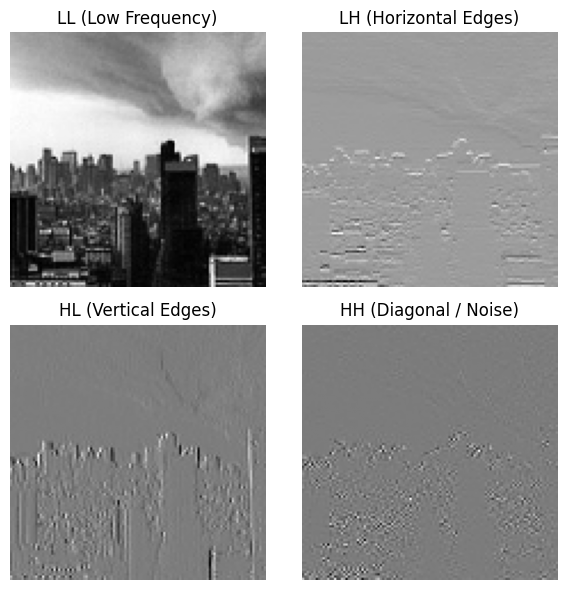

In [ ]:
# import cv2
# import pywt
# import matplotlib.pyplot as plt

# def visualize_dwt(patch_path):
#     # Load image
#     img = cv2.imread(patch_path)
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#     # Apply DWT
#     LL, (LH, HL, HH) = pywt.dwt2(img, 'haar')

#     # Plot
#     plt.figure(figsize=(6, 6))

#     plt.subplot(2, 2, 1)
#     plt.imshow(LL, cmap='gray')
#     plt.title("LL (Low Frequency)")
#     plt.axis("off")

#     plt.subplot(2, 2, 2)
#     plt.imshow(LH, cmap='gray')
#     plt.title("LH (Horizontal Edges)")
#     plt.axis("off")

#     plt.subplot(2, 2, 3)
#     plt.imshow(HL, cmap='gray')
#     plt.title("HL (Vertical Edges)")
#     plt.axis("off")

#     plt.subplot(2, 2, 4)
#     plt.imshow(HH, cmap='gray')
#     plt.title("HH (Diagonal / Noise)")
#     plt.axis("off")

#     plt.tight_layout()
#     plt.show()

# patch_path = "segmented_patches\\262741000764678145\\sandyA_fake_14_patch_224_224.jpg"

# visualize_dwt(patch_path)

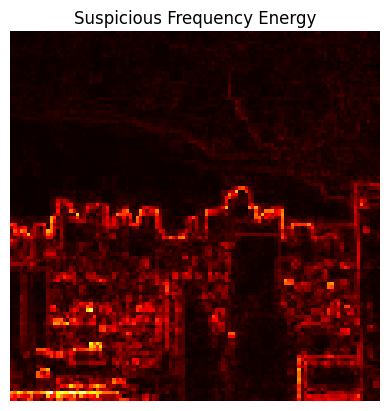

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import cv2

# def visualize_suspicious_energy(patch_path):
#     img = cv2.imread(patch_path)
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#     LL, (LH, HL, HH) = pywt.dwt2(img, 'haar')

#     # High-frequency energy
#     energy = np.abs(LH) + np.abs(HL) + np.abs(HH)

#     energy = cv2.normalize(energy, None, 0, 255, cv2.NORM_MINMAX)

#     plt.imshow(energy, cmap='hot')
#     plt.title("Suspicious Frequency Energy")
#     plt.axis("off")
#     plt.show()

# patch_path = "segmented_patches\\262741000764678145\\sandyA_fake_14_patch_224_224.jpg"

# visualize_suspicious_energy(patch_path)

In [ ]:
# class DWT_CNN_show(nn.Module):
#     def __init__(self, output_dim=256):
#         super().__init__()

#         self.conv1 = nn.Sequential(
#             nn.Conv2d(4, 32, 3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU()
#         )

#         self.pool1 = nn.MaxPool2d(2)

#         self.conv2 = nn.Sequential(
#             nn.Conv2d(32, 64, 3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU()
#         )

#         self.pool2 = nn.MaxPool2d(2)

#         self.conv3 = nn.Sequential(
#             nn.Conv2d(64, 128, 3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU()
#         )

#         self.pool3 = nn.AdaptiveAvgPool2d((1,1))

#         self.fc = nn.Linear(128, output_dim)

#     def forward(self, x, return_map=False):
#         x = self.conv1(x)
#         x = self.pool1(x)

#         x = self.conv2(x)
#         x = self.pool2(x)

#         feature_map = self.conv3(x)  # 🔥 IMPORTANT

#         x = self.pool3(feature_map)
#         x = x.view(x.size(0), -1)
#         x = self.fc(x)

#         if return_map:
#             return x, feature_map
#         return x

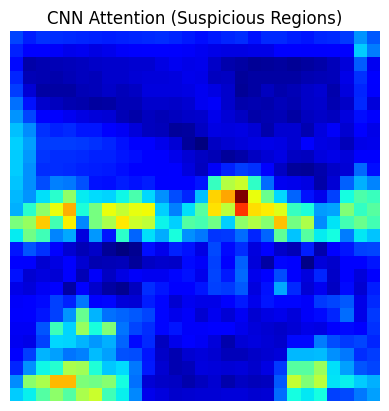

In [ ]:
# def visualize_cnn_attention(patch_path, model, device="cpu"):
#     img = preprocess_patch(patch_path)
#     tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(device)

#     with torch.no_grad():
#         _, fmap = model(tensor, return_map=True)

#     fmap = fmap.squeeze(0).cpu().numpy()  # (C,H,W)

#     # Average channels → attention map
#     attention = np.mean(fmap, axis=0)

#     attention = cv2.normalize(attention, None, 0, 255, cv2.NORM_MINMAX)

#     plt.imshow(attention, cmap='jet')
#     plt.title("CNN Attention (Suspicious Regions)")
#     plt.axis("off")
#     plt.show()

# model = DWT_CNN_show(output_dim=256).to(device)
# patch_path = "segmented_patches\\262741000764678145\\sandyA_fake_14_patch_224_224.jpg"
# visualize_cnn_attention(patch_path, model, device)

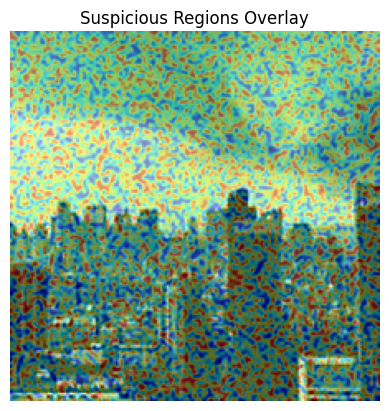

In [ ]:
# def overlay_attention(patch_path, attention):
#     img = cv2.imread(patch_path)
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#     attention = cv2.resize(attention, (img.shape[1], img.shape[0]))
#     attention = cv2.normalize(attention, None, 0, 255, cv2.NORM_MINMAX)

#     heatmap = cv2.applyColorMap(attention.astype(np.uint8), cv2.COLORMAP_JET)

#     overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

#     plt.imshow(overlay)
#     plt.title("Suspicious Regions Overlay")
#     plt.axis("off")
#     plt.show()

# patch_path = "segmented_patches\\262741000764678145\\sandyA_fake_14_patch_224_224.jpg"
# attention = np.random.rand(112, 112) * 255  # Dummy attention for demo
# overlay_attention(patch_path, attention)

## Spatial feature extraction of Images

In [11]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import os
from transformers import ViTModel, ViTImageProcessor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224")
vit_model = vit_model.to(device)
vit_model.eval()

processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
def extract_vit_feature_batch(patch_paths):

    images = []

    for p in patch_paths:
        img = Image.open(p).convert("RGB")
        images.append(img)

    inputs = processor(images=images, return_tensors="pt").to(device)

    # 🔥 VERY IMPORTANT
    vit_model.eval()

    with torch.no_grad():
        outputs = vit_model(**inputs)

    # CLS token → (B, 768)
    cls_features = outputs.last_hidden_state[:, 0, :]

    # Move to CPU for storage consistency
    return cls_features.cpu()

In [13]:
import os
import re

def extract_coords(name):
    match = re.search(r'_x(\d+)_y(\d+)', name)
    if match:
        return (int(match.group(1)), int(match.group(2)))
    return (0, 0)


def process_tweet_spatial(tweet_folder, batch_size=32):

    patch_files = [
        f for f in os.listdir(tweet_folder) if f.endswith(".jpg")
    ]

    # 🔥 Ensure consistent ordering
    patch_files = sorted(patch_files)

    features_dict = {}

    batch_paths = []
    batch_names = []

    for patch_file in patch_files:
        patch_path = os.path.join(tweet_folder, patch_file)

        batch_paths.append(patch_path)
        batch_names.append(patch_file)

        if len(batch_paths) == batch_size:
            feats = extract_vit_feature_batch(batch_paths)

            for name, feat in zip(batch_names, feats):
                features_dict[name] = {
                    "feature": feat.numpy(),
                    "coords": extract_coords(name)
                }

            batch_paths = []
            batch_names = []

    # leftover
    if len(batch_paths) > 0:
        feats = extract_vit_feature_batch(batch_paths)

        for name, feat in zip(batch_names, feats):
            features_dict[name] = {
                "feature": feat.numpy(),
                "coords": extract_coords(name)
            }

    return features_dict

In [14]:
def extract_all_spatial_features(root_dir):

    spatial_features = {}

    for tweet_id in os.listdir(root_dir):
        tweet_path = os.path.join(root_dir, tweet_id)

        if not os.path.isdir(tweet_path):
            continue

        # print(f"Processing spatial features: {tweet_id}")

        tweet_features = process_tweet_spatial(tweet_path)

        spatial_features[tweet_id] = tweet_features

    return spatial_features

In [15]:
root_dir = "segmented_patches"

spatial_features = extract_all_spatial_features(root_dir)

In [16]:
import pickle

with open("spatial_features_2.pkl", "wb") as f:
    pickle.dump(spatial_features, f)

In [17]:
import torch
import torch.nn as nn

class CoAttentionFusion(nn.Module):
    def __init__(self, spatial_dim=768, freq_dim=256, hidden_dim=256):
        super().__init__()

        self.spatial_proj = nn.Linear(spatial_dim, hidden_dim)
        self.freq_proj = nn.Linear(freq_dim, hidden_dim)

        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key   = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)

        self.scale = hidden_dim ** -0.5

        self.gamma = nn.Sequential(
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, spatial_feat, freq_feat):
        """
        spatial_feat: (B, 768)
        freq_feat:    (B, 256)
        """

        # Step 1: projection
        spatial = self.spatial_proj(spatial_feat)   # (B, H)
        freq    = self.freq_proj(freq_feat)         # (B, H)

        # Step 2: co-attention (correct formulation)
        Q = self.query(spatial)                    # (B, H)
        K = self.key(freq)                         # (B, H)
        V = self.value(freq)                       # (B, H)

        # 🔥 Proper attention score (dot product, not element-wise)
        attn_score = torch.sum(Q * K, dim=-1, keepdim=True) * self.scale  # (B,1)
        attn = torch.sigmoid(attn_score)  # scalar attention per sample

        co_attended = attn * V  # (B, H)

        # Step 3: adaptive fusion
        gamma = self.gamma(freq)  # (B,1)

        fused = spatial + gamma * co_attended

        return fused  # (B, H)

In [19]:
def fuse_features(spatial_features, freq_features, fusion_model, device):

    fusion_model.eval()

    fused_features = {}

    for tweet_id in spatial_features:

        fused_features[tweet_id] = {}

        for patch_name in spatial_features[tweet_id]:

            if patch_name not in freq_features[tweet_id]:
                continue

            spatial_entry = spatial_features[tweet_id][patch_name]
            freq_entry    = freq_features[tweet_id][patch_name]

            # 🔥 Extract feature + coords (consistent with earlier pipeline)
            spatial_feat = spatial_entry["feature"]
            freq_feat    = freq_entry["feature"]
            coords       = spatial_entry["coords"]  # assume same coords

            # Convert to tensor
            spatial = torch.from_numpy(spatial_feat).float().unsqueeze(0).to(device)
            freq    = torch.from_numpy(freq_feat).float().unsqueeze(0).to(device)

            with torch.no_grad():
                fused = fusion_model(spatial, freq)

            fused_features[tweet_id][patch_name] = {
                "feature": fused.squeeze(0).cpu().numpy(),
                "coords": coords
            }

    return fused_features

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"

fusion_model = CoAttentionFusion().to(device)

fused_img_features = fuse_features(
    spatial_features,
    frequency_features,   # your freq features
    fusion_model,
    device
)

In [21]:
with open("fused_img_features.pkl", "wb") as f:
    pickle.dump(fused_img_features, f)

## Graph Construction